In [1]:
import fsp_module as full
from metadata_module import read_metadata 

In [2]:
metadata = read_metadata()

In [3]:
metadata.shape[0]

51135

In [11]:
for row in metadata.to_dict(orient = "records"):
    print(row)

{'site': 'S00', 'patient_id': 'P32423', 'exam_id': '20220512-151756-{195a4196-0111-4fa5-a0a2-951e8335fa14}', 'age': 47.0, 'age_group': '46-55', 'female': 1, 'pathology': 1}
{'site': 'S00', 'patient_id': 'P28507', 'exam_id': '20220512-163015-{f7af3b95-1afd-4de4-8b7e-78c4670ee807}', 'age': 46.9, 'age_group': '46-55', 'female': 1, 'pathology': 0}
{'site': 'S00', 'patient_id': 'P28506', 'exam_id': '20220512-162932-{408352a4-978b-4b42-bff2-62db785a9555}', 'age': 40.6, 'age_group': '36-45', 'female': 0, 'pathology': 1}
{'site': 'S00', 'patient_id': 'P28505', 'exam_id': '20220512-162946-{3ad3c86b-3d61-440e-81df-b74fdba440c3}', 'age': 36.9, 'age_group': '36-45', 'female': 0, 'pathology': 1}
{'site': 'S00', 'patient_id': 'P28504', 'exam_id': '20220512-163006-{6e353308-dcd5-4cdd-9ae3-c3fa83f828b7}', 'age': 52.6, 'age_group': '46-55', 'female': 0, 'pathology': 1}
{'site': 'S00', 'patient_id': 'P28503', 'exam_id': '20220512-162912-{de1603f9-d0df-42b7-9d56-c47008cbf48b}', 'age': 17.7, 'age_group': 

In [4]:
id = 15000
row = metadata.iloc[id]
data = full.process(row)
print(data.shape)

(150, 17, 768)


In [5]:
data[10]

array([[ 3.16647605e-05,  2.42512999e-05,  2.16661391e-05, ...,
         5.49235347e-06, -1.10360628e-06, -2.22008044e-06],
       [ 2.10346044e-05,  1.92776868e-05,  1.77237795e-05, ...,
        -5.91540580e-06, -8.50983963e-06, -4.02578307e-06],
       [ 2.08474747e-05,  1.94967586e-05,  2.25334098e-05, ...,
        -2.02844728e-06, -8.86771072e-06, -1.19958134e-05],
       ...,
       [-5.36629252e-07, -8.11695983e-06, -1.31642533e-05, ...,
         2.79159254e-06,  3.39917390e-06,  4.85522516e-06],
       [-4.74775957e-08,  5.12610440e-06,  1.35765171e-05, ...,
         7.18030567e-06,  6.71176288e-06,  5.67851185e-06],
       [ 7.91735006e-07, -1.99565779e-06, -3.06939777e-06, ...,
         1.96982565e-06,  3.41731428e-06,  5.76613631e-06]],
      shape=(17, 768))

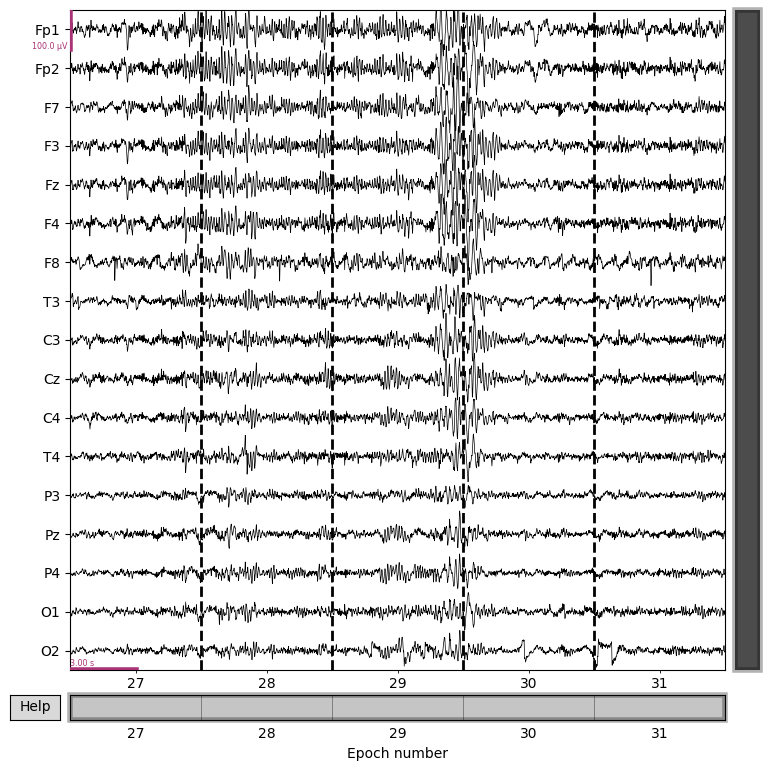

In [6]:
import mne
import config as c


info = mne.create_info(c.VALID_CHANNELS_AFTER_DROP, sfreq=c.DEFAULT_SFREQ, ch_types="eeg")  
epochs = mne.EpochsArray(data, info, tmin=0, baseline=None)
g = epochs[27:32].plot(n_epochs=5, scalings=dict(eeg=50e-6))
